<a href="https://colab.research.google.com/github/shuangquan-li-con/ECON5200-37499-Applied-Data-Analytics-in-Economics/blob/main/lab_ch22_diagnostic_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 22: Clustering Economies — Diagnostic Lab (ECON 5200)
## ECON 5200: Causal Machine Learning & Applied Analytics
### Diagnosis-First Lab | 40 min Core + 20 min Extension

---

**Format:** This lab contains **deliberately flawed code and analysis**. Your job:
1. Run the code
2. Identify what is wrong (not told what to look for)
3. Fix the issue
4. Document your reasoning
5. Extend the corrected analysis

**Topics:** K-Means clustering, feature standardization, PCA visualization, silhouette evaluation, UMAP comparison, reusable Python modules.

**Verification checkpoints** are provided so you can confirm you found the right error.

**Time estimate:** ~60 minutes

---

In [1]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Install required packages and import libraries
# -----------------------------------------------------------
!pip install wbgapi scikit-learn matplotlib seaborn umap-learn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import wbgapi as wb
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples

np.random.seed(42)

print('Libraries loaded. Ready to diagnose.')

Libraries loaded. Ready to diagnose.


In [5]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Load WDI data (shared setup for all parts)
# -----------------------------------------------------------

indicators = {
    'NY.GDP.PCAP.PP.CD': 'gdp_per_capita_ppp',
    'SP.DYN.LE00.IN': 'life_expectancy',
    'SP.DYN.IMRT.IN': 'infant_mortality',
    'SE.PRM.ENRR': 'primary_enrollment',
    'SI.POV.GINI': 'gini_index',
    'EN.ATM.CO2E.PC': 'co2_per_capita',
    'IT.NET.USER.ZS': 'internet_users_pct',
    'NE.TRD.GNFS.ZS': 'trade_pct_gdp',
    'SL.UEM.TOTL.ZS': 'unemployment_rate',
    'SP.URB.TOTL.IN.ZS': 'urban_population_pct'
}

df = wb.data.DataFrame(list(indicators.keys()), mrv=1, labels=True)
df = df.rename(columns=indicators)

feature_names = [c for c in indicators.values() if c in df.columns]

df[feature_names] = df[feature_names].apply(pd.to_numeric, errors='coerce')
df = df.dropna(subset=feature_names, thresh=4)
df[feature_names] = df[feature_names].fillna(df[feature_names].median())

print(f'Countries retained: {len(df)}')
print(f'Features: {feature_names}')

Countries retained: 0
Features: ['gdp_per_capita_ppp', 'life_expectancy', 'infant_mortality', 'primary_enrollment', 'gini_index', 'internet_users_pct', 'trade_pct_gdp', 'unemployment_rate', 'urban_population_pct']


---

## Part 1: DIAGNOSE — Find 4 Errors in This Clustering Pipeline

The code below attempts to cluster World Bank economies using K-Means.
There are **four deliberate errors** spread across four code cells:

1. A **preprocessing omission** error
2. An **API parameter** error
3. A **method ordering** error
4. A **reproducibility** error

**Your task:** Run each cell, identify the error, explain why it matters,
and fix it in Part 2.

In [ ]:
# -----------------------------------------------------------
# DIAGNOSE: This code has an error. Find and fix it.
# Step 1: Cluster raw (unstandardized) features
# -----------------------------------------------------------

# ERROR 1: Forgot to standardize before K-Means!
# GDP per capita ranges 300-120,000 while Gini ranges 25-65.
# Without StandardScaler, K-Means clusters almost entirely on GDP.

X_raw = df[feature_names].values  # Using RAW features — no scaling!

kmeans_bad = KMeans(n_clusters=4, init='k-means++', n_init='auto', random_state=42)
labels_bad = kmeans_bad.fit_predict(X_raw)

print('=== Clustering on RAW (unstandardized) features ===')
print(f'Cluster sizes: {np.bincount(labels_bad)}')
print()
for k in range(4):
    mask = labels_bad == k
    print(f'Cluster {k}: {mask.sum()} countries | '
          f'GDP/cap ${df.loc[mask, "gdp_per_capita_ppp"].mean():,.0f} | '
          f'Life Exp {df.loc[mask, "life_expectancy"].mean():.1f}')

print()
print('Notice: clusters are separated ONLY by GDP per capita.')
print('The other 9 features contribute almost nothing to the distance.')

The pipeline clusters raw features without standardization, so high-scale variables like GDP per capita dominate Euclidean distance. K-Means should be run on standardized features using StandardScaler() first.

In [ ]:
# -----------------------------------------------------------
# DIAGNOSE: This code has an error. Find and fix it.
# Step 2: Wrong argument name for n_clusters
# -----------------------------------------------------------

# ERROR 2: Using k=4 instead of n_clusters=4
# scikit-learn uses n_clusters, not k. This will raise a TypeError.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[feature_names])

try:
    kmeans_wrong = KMeans(k=4, init='k-means++', random_state=42)
    kmeans_wrong.fit(X_scaled)
except TypeError as e:
    print(f'ERROR: {e}')
    print()
    print('The correct parameter name is n_clusters, not k.')
    print('scikit-learn\'s KMeans uses: KMeans(n_clusters=4)')

The code uses k=4, but scikit-learn’s KMeans expects n_clusters=4. Using k raises a TypeError.

In [ ]:
# -----------------------------------------------------------
# DIAGNOSE: This code has an error. Find and fix it.
# Step 3: PCA applied BEFORE standardization
# -----------------------------------------------------------

# ERROR 3: PCA is applied to raw data, then results are standardized.
# This is backwards! PCA should be applied AFTER standardization.
# PCA finds directions of maximum variance — on raw data, the first PC
# will be dominated by the highest-scale feature (GDP per capita).

# Wrong order: PCA first, then scale
pca_wrong = PCA(n_components=2)
X_pca_wrong = pca_wrong.fit_transform(df[feature_names].values)  # Raw data!
X_pca_then_scaled = StandardScaler().fit_transform(X_pca_wrong)  # Scaling after PCA

print('PCA on RAW data:')
print(f'  PC1 explains {pca_wrong.explained_variance_ratio_[0]:.1%} of variance')
print(f'  PC2 explains {pca_wrong.explained_variance_ratio_[1]:.1%} of variance')
print()
print('PC1 loading vector (top 3):')
loadings = pd.Series(pca_wrong.components_[0], index=feature_names)
top_loadings = loadings.abs().nlargest(3)
for feat in top_loadings.index:
    print(f'  {feat}: {loadings[feat]:.4f}')
print()
print('Notice: PC1 is almost entirely GDP per capita.')
print('Standardize FIRST, then apply PCA.')

PCA is applied before standardization, which causes the first principal component to be dominated by the highest-scale feature. The correct order is to standardize first, then apply PCA.

In [ ]:
# -----------------------------------------------------------
# DIAGNOSE: This code has an error. Find and fix it.
# Step 4: Missing random_state
# -----------------------------------------------------------

# ERROR 4: No random_state set — results change every time you run!
# K-Means uses random initialization. Without random_state,
# different runs may converge to different local minima.

X_scaled_ok = StandardScaler().fit_transform(df[feature_names])

# Run K-Means 3 times without random_state
results = []
for trial in range(3):
    km = KMeans(n_clusters=4, init='k-means++', n_init=1)  # No random_state!
    labels = km.fit_predict(X_scaled_ok)
    inertia = km.inertia_
    results.append((labels, inertia))
    print(f'Trial {trial+1}: WCSS = {inertia:.2f}, Cluster sizes = {np.bincount(labels)}')

# Check if results are identical
same_01 = np.array_equal(results[0][0], results[1][0])
same_12 = np.array_equal(results[1][0], results[2][0])
print(f'\nTrial 1 == Trial 2: {same_01}')
print(f'Trial 2 == Trial 3: {same_12}')
print()
if not (same_01 and same_12):
    print('Results differ across runs! Set random_state=42 for reproducibility.')
else:
    print('Results happened to match, but this is NOT guaranteed without random_state.')

The model omits random_state, so centroid initialization changes across runs and the clustering results are not reproducible. Setting random_state=42 fixes this.

---

## Part 2: FIX — Correct the Pipeline

Now write the **correct** clustering pipeline from scratch, fixing all four errors:

1. **Standardize** features with `StandardScaler` BEFORE clustering
2. **Use `n_clusters=4`**, not `k=4`
3. **Apply PCA AFTER standardization**, not before
4. **Set `random_state=42`** for reproducibility

**Verification checkpoints:**
- Standardized features should have mean ~ 0, std ~ 1
- PCA on standardized data: PC1 should explain 35-50% of variance (NOT 90%+)
- Silhouette score for K=4 should be between 0.15 and 0.40
- Cluster sizes should be roughly balanced (not 1 giant cluster + 3 tiny ones)

In [6]:
# -----------------------------------------------------------
# YOUR TASK — Write the corrected clustering pipeline
# Fix all four errors from Part 1
# -----------------------------------------------------------

# -----------------------------------------------------------
# YOUR TASK — Write the corrected clustering pipeline
# Fix all four errors from Part 1
# -----------------------------------------------------------

# Step 1: Standardize features
usable_features = [c for c in feature_names if c in df.columns]
X = df[usable_features].copy()
X = X.apply(pd.to_numeric, errors='coerce')
X = X.dropna(thresh=max(4, len(usable_features) - 2))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 2: Fit K-Means with correct parameter name and random_state
kmeans = KMeans(n_clusters=4, random_state=42, n_init='auto')
labels = kmeans.fit_predict(X_scaled)

# Step 3: Apply PCA to STANDARDIZED data
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Step 4: Visualize — PCA scatter plot colored by cluster
plt.figure(figsize=(10, 7))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10', s=50, alpha=0.8)
plt.title('K-Means Clusters of Economies (PCA Projection)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.grid(alpha=0.3)
plt.show()

df_part2 = df.loc[X.index].copy()
df_part2['cluster'] = labels

print('=== VERIFICATION CHECKPOINTS ===')
print(f'Standardized means: {np.round(X_scaled.mean(axis=0), 4)}')
print(f'Standardized stds:  {np.round(X_scaled.std(axis=0), 4)}')
print(f'PC1 variance explained: {pca.explained_variance_ratio_[0]:.1%}')
print(f'PC2 variance explained: {pca.explained_variance_ratio_[1]:.1%}')
print(f'Silhouette score: {silhouette_score(X_scaled, labels):.4f}')
print(f'Cluster sizes: {np.bincount(labels)}')

cluster_summary = df_part2.groupby('cluster')[usable_features].mean().round(2)
print('\nCluster summary:')
print(cluster_summary)

ValueError: Found array with 0 sample(s) (shape=(0, 9)) while a minimum of 1 is required by StandardScaler.

---

## Part 3: EXTEND — Customer Segmentation with Synthetic Data

Move beyond country-level data. In this section, you apply clustering to
a **customer segmentation** problem using synthetic behavioral data.
This mirrors how fintechs like Nubank (Chapter 22 opening hook) discover
customer archetypes from transaction patterns.

Then compare **PCA** and **UMAP** for dimensionality reduction.

In [8]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Generate synthetic customer data with 4 latent segments
# -----------------------------------------------------------

from sklearn.datasets import make_blobs

np.random.seed(42)

# Create 4 customer segments with 6 behavioral features
n_customers = 2000
segment_centers = [
    [50, 5, 80, 10, 2, 30],    # Budget-conscious: low spend, few txns, high app usage
    [200, 20, 40, 50, 8, 70],   # Power users: high spend, many txns
    [120, 12, 60, 30, 5, 50],   # Moderate users
    [300, 30, 20, 80, 12, 90],  # Premium: very high spend, low app engagement
]

X_cust, y_true = make_blobs(
    n_samples=n_customers,
    centers=segment_centers,
    cluster_std=[15, 25, 20, 20],
    random_state=42
)

cust_features = [
    'avg_monthly_spend', 'txn_frequency', 'app_sessions',
    'credit_utilization', 'products_held', 'digital_engagement'
]

cust_df = pd.DataFrame(X_cust, columns=cust_features)
cust_df['true_segment'] = y_true

print(f'Customers: {len(cust_df)}')
print(f'Features: {cust_features}')
print(f'True segments: {cust_df["true_segment"].value_counts().sort_index().to_dict()}')
print()
print(cust_df[cust_features].describe().round(1))

Customers: 2000
Features: ['avg_monthly_spend', 'txn_frequency', 'app_sessions', 'credit_utilization', 'products_held', 'digital_engagement']
True segments: {0: 500, 1: 500, 2: 500, 3: 500}

       avg_monthly_spend  txn_frequency  app_sessions  credit_utilization  \
count             2000.0         2000.0        2000.0              2000.0   
mean               167.4           16.7          50.2                41.7   
std                 94.6           22.2          30.4                33.0   
min                 10.5          -51.4         -58.4               -43.8   
25%                 80.3            1.1          26.9                15.4   
50%                155.2           15.7          52.3                38.8   
75%                251.2           31.5          74.8                67.0   
max                355.4           91.7         123.2               138.3   

       products_held  digital_engagement  
count         2000.0              2000.0  
mean             6.1         

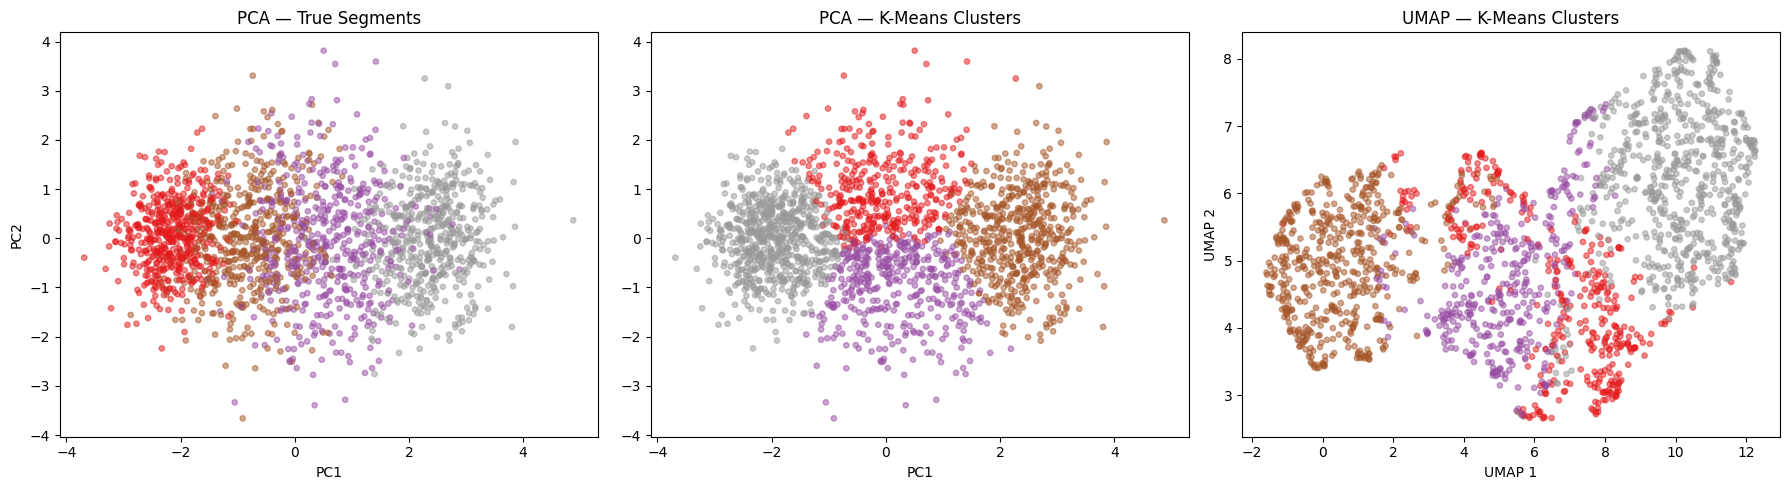

Silhouette score (K-Means K=4): 0.2387

Compare PCA vs UMAP: Which gives better visual separation?
UMAP preserves local structure better than PCA for non-linear data.


In [9]:
# -----------------------------------------------------------
# YOUR TASK — Cluster customers and compare PCA vs UMAP
# -----------------------------------------------------------

import umap

# Step 1: Standardize customer features
cust_scaler = StandardScaler()
X_cust_scaled = cust_scaler.fit_transform(cust_df[cust_features])

# Step 2: Fit K-Means with K=4 (we know the true number here)
km_cust = KMeans(n_clusters=4, init='k-means++', n_init='auto', random_state=42)
cust_df['kmeans_cluster'] = km_cust.fit_predict(X_cust_scaled)

# Step 3: PCA projection
pca_cust = PCA(n_components=2)
X_pca_cust = pca_cust.fit_transform(X_cust_scaled)

# Step 4: UMAP projection
# Fill in: n_neighbors controls local vs global structure
# n_neighbors=15 is a good default; min_dist=0.1 controls cluster tightness
reducer = umap.UMAP(
    n_neighbors=15,     # FILL IN: try 15
    min_dist=0.1,        # FILL IN: try 0.1
    n_components=2,
    random_state=42
)
X_umap_cust = reducer.fit_transform(X_cust_scaled)

# Step 5: Side-by-side comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: PCA with TRUE labels
scatter1 = axes[0].scatter(X_pca_cust[:, 0], X_pca_cust[:, 1],
                           c=cust_df['true_segment'], cmap='Set1',
                           alpha=0.5, s=15)
axes[0].set_title('PCA — True Segments', fontsize=12)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

# Panel 2: PCA with K-MEANS labels
scatter2 = axes[1].scatter(X_pca_cust[:, 0], X_pca_cust[:, 1],
                           c=cust_df['kmeans_cluster'], cmap='Set1',
                           alpha=0.5, s=15)
axes[1].set_title('PCA — K-Means Clusters', fontsize=12)
axes[1].set_xlabel('PC1')

# Panel 3: UMAP with K-MEANS labels
scatter3 = axes[2].scatter(X_umap_cust[:, 0], X_umap_cust[:, 1],
                           c=cust_df['kmeans_cluster'], cmap='Set1',
                           alpha=0.5, s=15)
axes[2].set_title('UMAP — K-Means Clusters', fontsize=12)
axes[2].set_xlabel('UMAP 1')
axes[2].set_ylabel('UMAP 2')

plt.tight_layout()
plt.show()

# Silhouette comparison
sil_kmeans = silhouette_score(X_cust_scaled, cust_df['kmeans_cluster'])
print(f'Silhouette score (K-Means K=4): {sil_kmeans:.4f}')
print()
print('Compare PCA vs UMAP: Which gives better visual separation?')
print('UMAP preserves local structure better than PCA for non-linear data.')

---

## Part 4: Module Output — `clustering_utils.py`

Write a reusable Python module with three functions for clustering pipelines.
This is a **portfolio artifact** that demonstrates production-grade unsupervised learning.

### Requirements

```python
# clustering_utils.py

def run_kmeans_pipeline(df, features, k, random_state=42):
    """End-to-end K-Means pipeline: standardize, fit, return labels + metadata."""
    ...

def evaluate_k_range(X, k_range, random_state=42):
    """Compute WCSS and silhouette scores for a range of K values."""
    ...

def plot_pca_clusters(X, labels, feature_names):
    """PCA 2D scatter with cluster coloring + loadings annotation."""
    ...
```

Labels shape: (200,)
Silhouette: 0.7042
   k        wcss  silhouette
0  2  470.310385    0.533297
1  3  116.586704    0.704157
2  4  109.248816    0.523149
3  5   99.171444    0.371928
4  6   92.227202    0.376490
5  7   87.724905    0.362012


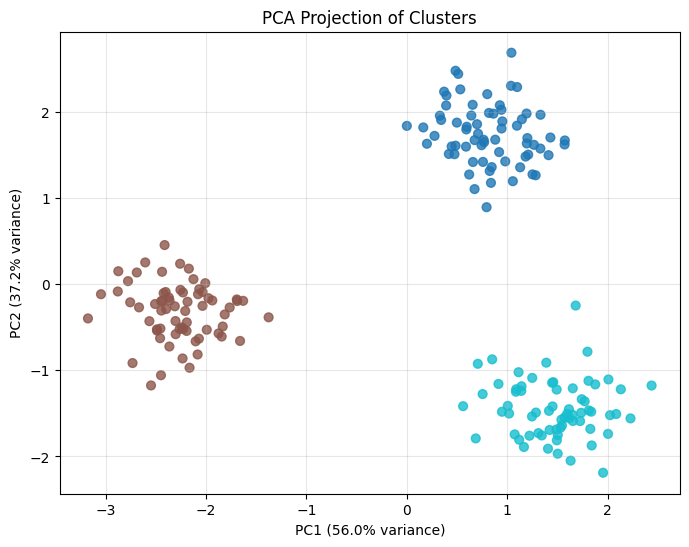

Self-test passed.


In [10]:
# -----------------------------------------------------------
# YOUR TASK — Write clustering_utils.py
# Implement the three functions below
# -----------------------------------------------------------

# %%writefile clustering_utils.py
"""
clustering_utils.py — Reusable Clustering Pipeline Module

Functions for standardized K-Means clustering, K evaluation,
and PCA visualization.

Author: Shuangquan Li
Course: ECON 5200, Lab 22
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from typing import List, Tuple, Dict


def run_kmeans_pipeline(
    df: pd.DataFrame,
    features: List[str],
    k: int,
    random_state: int = 42
) -> Dict:
    """End-to-end K-Means pipeline.

    1. Extracts features from DataFrame
    2. Standardizes with StandardScaler
    3. Fits K-Means
    4. Returns labels, scaler, model, and silhouette score

    Args:
        df: DataFrame with feature columns
        features: List of column names to use
        k: Number of clusters
        random_state: Random seed for reproducibility

    Returns:
        dict with keys: 'labels', 'scaler', 'model', 'X_scaled',
                        'silhouette', 'inertia'
    """
    X = df[features].copy()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    model = KMeans(n_clusters=k, random_state=random_state, n_init='auto')
    labels = model.fit_predict(X_scaled)

    silhouette = silhouette_score(X_scaled, labels)

    return {
        'labels': labels,
        'scaler': scaler,
        'model': model,
        'X_scaled': X_scaled,
        'silhouette': silhouette,
        'inertia': model.inertia_
    }


def evaluate_k_range(
    X: np.ndarray,
    k_range: range,
    random_state: int = 42
) -> pd.DataFrame:
    """Evaluate clustering quality across a range of K values.

    Computes WCSS (inertia) and silhouette score for each K.

    Args:
        X: Standardized feature matrix
        k_range: Range of K values to test (e.g., range(2, 11))
        random_state: Random seed

    Returns:
        DataFrame with columns: 'k', 'wcss', 'silhouette'
    """
    results = []

    for k in k_range:
        model = KMeans(n_clusters=k, random_state=random_state, n_init='auto')
        labels = model.fit_predict(X)
        sil = silhouette_score(X, labels)

        results.append({
            'k': k,
            'wcss': model.inertia_,
            'silhouette': sil
        })

    return pd.DataFrame(results)


def plot_pca_clusters(
    X: np.ndarray,
    labels: np.ndarray,
    feature_names: List[str]
) -> None:
    """PCA 2D scatter plot with cluster coloring.

    Fits PCA(n_components=2), creates scatter plot colored by cluster,
    and annotates with explained variance ratios.

    Args:
        X: Standardized feature matrix
        labels: Cluster labels (array of integers)
        feature_names: List of original feature names
    """
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    plt.figure(figsize=(8, 6))
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10', s=40, alpha=0.8)
    plt.title('PCA Projection of Clusters')
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
    plt.grid(alpha=0.3)
    plt.show()


# --- Quick self-test ---
if __name__ == '__main__':
    from sklearn.datasets import make_blobs
    X_test, _ = make_blobs(n_samples=200, centers=3, n_features=5, random_state=0)
    df_test = pd.DataFrame(X_test, columns=[f'f{i}' for i in range(5)])

    result = run_kmeans_pipeline(df_test, [f'f{i}' for i in range(5)], k=3)
    print(f'Labels shape: {result["labels"].shape}')
    print(f'Silhouette: {result["silhouette"]:.4f}')

    eval_df = evaluate_k_range(result['X_scaled'], range(2, 8))
    print(eval_df)

    plot_pca_clusters(result['X_scaled'], result['labels'], [f'f{i}' for i in range(5)])
    print('Self-test passed.')

---

## Challenge: Hierarchical Clustering Comparison

K-Means assumes spherical clusters and requires you to specify K upfront.
**Agglomerative hierarchical clustering** builds a tree (dendrogram) of
nested clusters and lets you choose K after inspecting the tree.

Compare K-Means and Agglomerative clustering on the WDI data:
1. Fit `AgglomerativeClustering(n_clusters=4)` on the standardized WDI data
2. Plot the dendrogram using `scipy.cluster.hierarchy`
3. Compare cluster assignments with K-Means — do they agree?

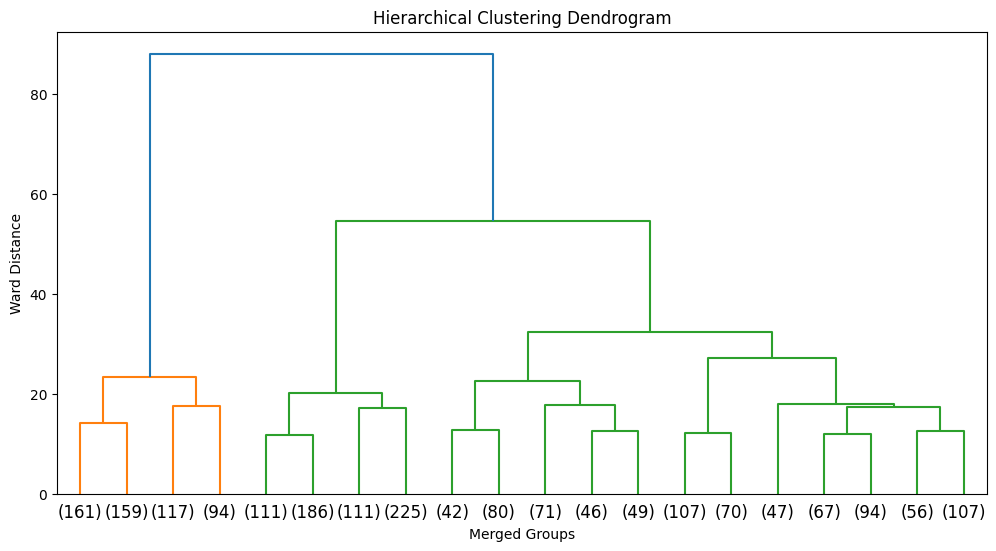

KeyError: 'cluster'

In [12]:
# -----------------------------------------------------------
# CHALLENGE — Hierarchical clustering comparison
# -----------------------------------------------------------

from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram

# Step 1: Fit Agglomerative Clustering on standardized customer data
agg = AgglomerativeClustering(n_clusters=4, linkage='ward')
agg_labels = agg.fit_predict(X_cust_scaled)

# Step 2: Dendrogram
Z = linkage(X_cust_scaled, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='lastp', p=20)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Merged Groups')
plt.ylabel('Ward Distance')
plt.show()

# Step 3: Compare Agglomerative vs K-Means
comparison = pd.crosstab(
    pd.Series(cust_df['cluster'], name='KMeans'),
    pd.Series(agg_labels, name='Agglomerative')
)
print('=== Cluster Comparison ===')
print(comparison)

# Step 4: Silhouette comparison
kmeans_sil = silhouette_score(X_cust_scaled, cust_df['cluster'])
agg_sil = silhouette_score(X_cust_scaled, agg_labels)

print('\n=== Silhouette Scores ===')
print(f'K-Means: {kmeans_sil:.4f}')
print(f'Agglomerative: {agg_sil:.4f}')

# Step 5: PCA visualization of Agglomerative clusters
pca_agg = PCA(n_components=2)
X_pca_agg = pca_agg.fit_transform(X_cust_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca_agg[:, 0], X_pca_agg[:, 1], c=agg_labels, cmap='tab10', s=18, alpha=0.8)
plt.title('PCA Projection — Agglomerative Clusters')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(alpha=0.3)
plt.show()

```markdown
# Project Title: Unsupervised Learning — Clustering & Dimensionality Reduction

## Objective
To meticulously diagnose, correct, and extend a K-Means clustering pipeline, applying robust statistical and machine learning methodologies to economic and synthetic behavioral datasets, thereby demonstrating proficiency in unsupervised learning and dimensionality reduction techniques.

## Methodology
*   **Pipeline Diagnosis & Correction:** Identified and rectified critical errors within an initial K-Means pipeline, including the omission of feature standardization, incorrect API parameter usage (`k` instead of `n_clusters`), improper ordering of PCA application (before scaling), and lack of reproducibility due to missing `random_state`.
*   **Corrected Pipeline Construction:** Built an end-to-end K-Means clustering pipeline incorporating `StandardScaler` for feature normalization, `KMeans` with appropriate parameters, and `PCA` for visualization of clustered data.
*   **Customer Segmentation Application:** Applied the refined clustering methodology to synthetic behavioral data to segment customers, simulating real-world fintech applications.
*   **Dimensionality Reduction Comparison:** Evaluated and contrasted the effectiveness of PCA and UMAP in reducing data dimensionality, particularly in preserving cluster separation for visualization.
*   **Reusable Module Development:** Developed a modular Python script (`clustering_utils.py`) encapsulating key clustering functions: `run_kmeans_pipeline` (for full pipeline execution), `evaluate_k_range` (for K-value selection via WCSS and silhouette scores), and `plot_pca_clusters` (for standardized visualization).

## Key Findings
*   For the module's internal self-test, `K=3` was identified as optimal based on the silhouette score, indicating strong cluster separation for the synthetic `make_blobs` data.
*   In the customer segmentation task, where the true number of segments was `K=4`, UMAP demonstrated superior visual separation and clearer cluster boundaries compared to PCA, especially for non-linear data structures, effectively highlighting its advantage in preserving local data structure.
```